In [ ]:
import pandas as pd              # Data handling
import numpy as np               # Numbers and arrays
import matplotlib.pyplot as plt  # Create graphs
import seaborn as sns            # Data visualization

In [ ]:
# Read the ARFF file manually (it was saved as df.md but the content is ARFF format)
with open('../data/raw/Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

# Column names, in the order they appear in @ATTRIBUTE lines
columns = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
           'Eccentricity', 'Convex_Area', 'Extent', 'Class']

# Find where the actual data starts (after the @DATA line)
data_start = next(i for i, l in enumerate(lines) if l.strip().upper() == '@DATA') + 1
data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

# Parse into a DataFrame
rows = [l.split(',') for l in data_lines]
df = pd.DataFrame(rows, columns=columns)

# Convert numeric columns from text to actual numbers
num_cols = columns[:-1]
df[num_cols] = df[num_cols].astype(float)

# Save a clean CSV for every other notebook to reuse
df.to_csv('../data/raw/rice.csv', index=False)

print(df.shape)
df.head()

(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [7]:
print(df)

         Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0     15231.0  525.578979         229.749878          85.093788      0.928882   
1     14656.0  494.311005         206.020065          91.730972      0.895405   
2     14634.0  501.122009         214.106781          87.768288      0.912118   
3     13176.0  458.342987         193.337387          87.448395      0.891861   
4     14688.0  507.166992         211.743378          89.312454      0.906691   
...       ...         ...                ...                ...           ...   
3805  11441.0  415.858002         170.486771          85.756592      0.864280   
3806  11625.0  421.390015         167.714798          89.462570      0.845850   
3807  12437.0  442.498993         183.572922          86.801979      0.881144   
3808   9882.0  392.296997         161.193985          78.210480      0.874406   
3809  11434.0  404.709991         161.079269          90.868195      0.825692   

      Convex_Area    Extent

In [8]:

df.describe().T[['mean','std','min','max']]

,mean,std,min,max
Area,12667.727559,1732.367706,7551.000000,18913.000000
Perimeter,454.239180,35.597081,359.100006,548.445984
Major_Axis_Length,188.776222,17.448679,145.264465,239.010498
Minor_Axis_Length,86.313750,5.729817,59.532406,107.542450
Eccentricity,0.886871,0.020818,0.777233,0.948007
Convex_Area,12952.496850,1776.972042,7723.000000,19099.000000
Extent,0.661934,0.077239,0.497413,0.861050


In [ ]:
# Standardization (Z-score scaling)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

num_cols = df.columns[:-1]
# Select all columns except the last column (target)

scaler_std = StandardScaler()
# Create a StandardScaler

df_std = df.copy()
# Make a copy of the original data

df_std[num_cols] = scaler_std.fit_transform(df[num_cols])
# Scale the feature columns using StandardScaler

df_std[num_cols].describe().T[['mean','std']]
# Check the mean and standard deviation after scaling
# Mean should be close to 0 and std should be close to 1


,mean,std
Area,0.000000e+00,1.000131
Perimeter,-1.193563e-16,1.000131
Major_Axis_Length,0.000000e+00,1.000131
Minor_Axis_Length,-5.371032e-16,1.000131
Eccentricity,5.669422e-16,1.000131
Convex_Area,-4.774250e-16,1.000131
Extent,-4.923446e-16,1.000131


In [ ]:
# Min-Max Scaling (0-1 range)

scaler_mm = MinMaxScaler()  # Create a Min-Max Scaler

df_minmax = df.copy() # Make a copy of the original data
df_minmax[num_cols] = scaler_mm.fit_transform(df[num_cols])  # Scale the feature columns to 0-1 range
df_minmax[num_cols].describe().T[['min','max']]  # Check the minimum and maximum values

# Min should be 0 and max should be 1

,min,max
Area,0.0,1.0
Perimeter,0.0,1.0
Major_Axis_Length,0.0,1.0
Minor_Axis_Length,0.0,1.0
Eccentricity,0.0,1.0
Convex_Area,0.0,1.0
Extent,0.0,1.0


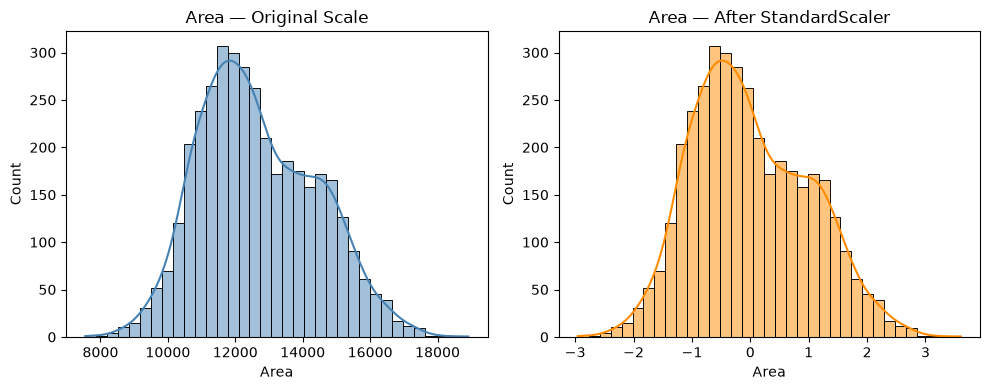

In [ ]:
# Before vs After Scaling

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Create two plots side by side
sns.histplot(df['Area'], kde=True, ax=axes[0], color='steelblue')  # Plot the original Area data

axes[0].set_title('Area — Original Scale')         # Set the title for the first plot
sns.histplot(df_std['Area'], kde=True, ax=axes[1], color='darkorange')         # Plot the scaled Area data
axes[1].set_title('Area — After StandardScaler')             # Set the title for the second plot

plt.tight_layout() # Adjust the spacing between plots
plt.savefig('../results/eda_visualizations/member4_scaling_histogram.png', dpi=150)  # Save the plots as an image
plt.show()  # Display the plots
